# Wine Quality Prediction using Machine Learning

### Importing all required library

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

### Load the Dataset

In [3]:
df = pd.read_csv("winequality (1) (1).csv")

## Viewing the dataset

### 1st 5 rows

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Last 5 rows

In [5]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


### Shape

In [6]:
df.shape

(1599, 12)

### Columns

In [7]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

### Basic infomation

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


### Statistical summary

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


### Check null values

In [10]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

### Analyze Correlation with quality

In [11]:
correlation = df.corr()["quality"].sort_values(ascending=False)

correlation

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

**Correlation Analysis**

- **Alcohol (0.476):** Strongest positive correlation with wine quality.
- **Sulphates (0.251):** Moderate positive relationship.
- **Citric Acid (0.226):** Positive relationship with quality.
- **Volatile Acidity (-0.391):** Strongest negative correlation.
- **Total Sulfur Dioxide (-0.185):** Negative relationship.
- **Density (-0.175):** Negative relationship.
- **Residual Sugar (0.014):** Almost no linear relationship.

The `quality` correlation of **1.0** is ignored because it represents the correlation of the `quality` column with itself.

## EDA (Expolatory Data Analysis)

### Distribution of fixed acidity

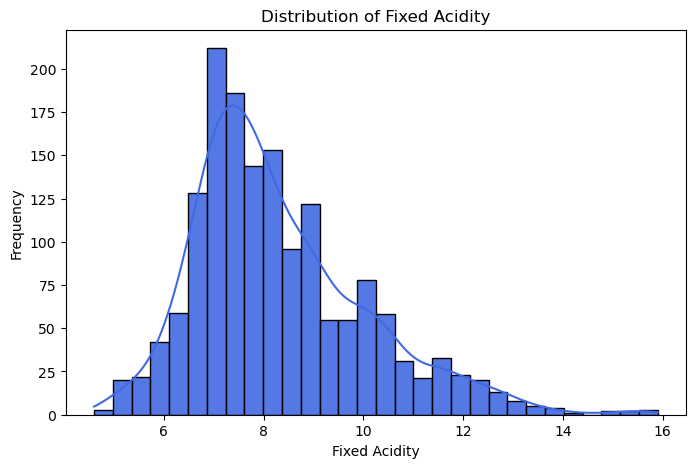

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="fixed acidity",
    bins=30,
    kde=True,
    color='royalblue',
    alpha=0.9
)

plt.title("Distribution of Fixed Acidity")
plt.xlabel("Fixed Acidity")
plt.ylabel("Frequency")

plt.show()

### Distribution of volatile acidity

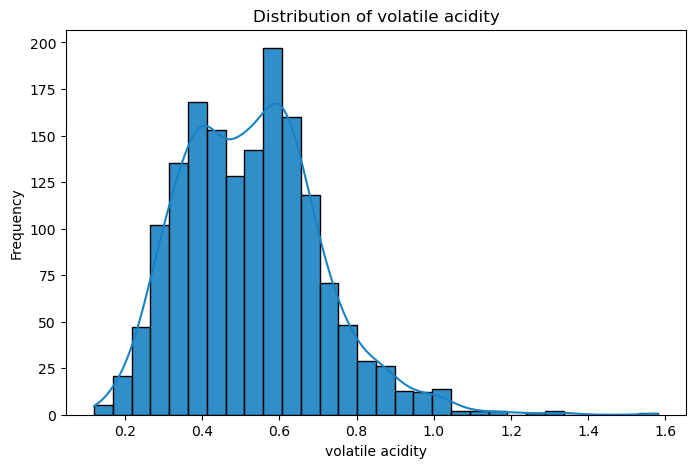

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="volatile acidity",
    bins=30,
    kde=True,
    color='#1982C4',
    alpha=0.9
)

plt.title("Distribution of volatile acidity")
plt.xlabel("volatile acidity")
plt.ylabel("Frequency")

plt.show()

### Distribution of citric acid	

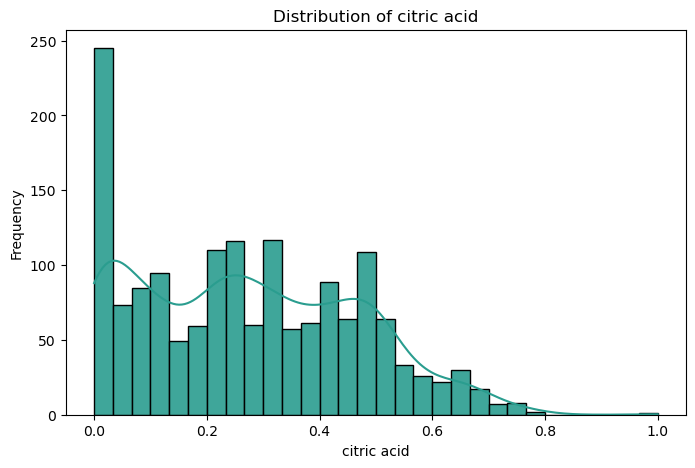

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="citric acid",
    bins=30,
    kde=True,
    color="#2A9D8F",
    alpha=0.9
)

plt.title("Distribution of citric acid")
plt.xlabel("citric acid")
plt.ylabel("Frequency")

plt.show()

### Distribution of residual sugar

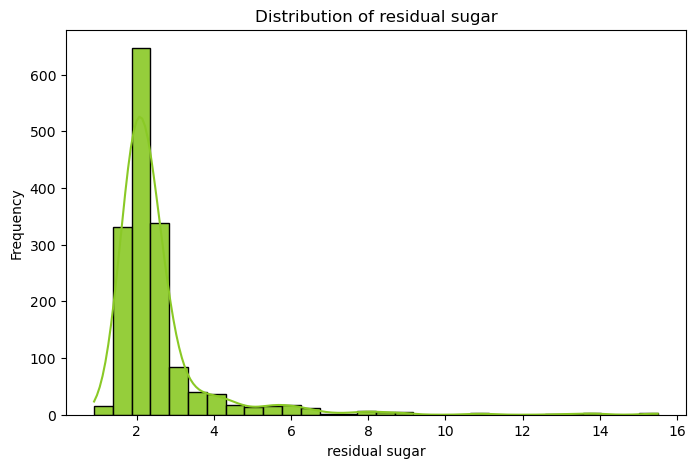

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="residual sugar",
    bins=30,
    kde=True,
    color="#8AC926",
    alpha=0.9
)

plt.title("Distribution of residual sugar")
plt.xlabel("residual sugar")
plt.ylabel("Frequency")

plt.show()

### Distribution of chlorides

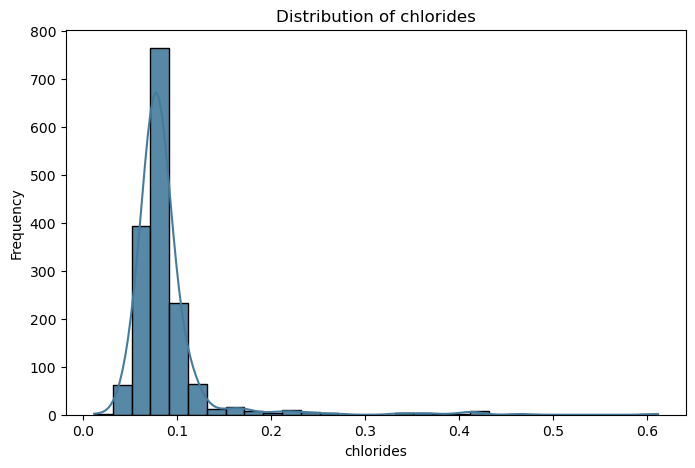

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="chlorides",
    bins=30,
    kde=True,
    color="#457B9D",
    alpha=0.9
)

plt.title("Distribution of chlorides")
plt.xlabel("chlorides")
plt.ylabel("Frequency")

plt.show()

### Distribution of free sulfur dioxide	

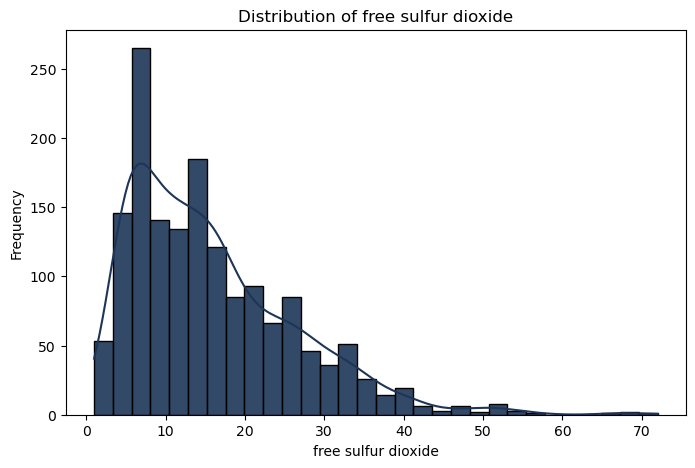

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="free sulfur dioxide",
    bins=30,
    kde=True,
    color="#1D3557",
    alpha=0.9
)

plt.title("Distribution of free sulfur dioxide")
plt.xlabel("free sulfur dioxide")
plt.ylabel("Frequency")

plt.show()

### Distribution of total sulfur dioxide

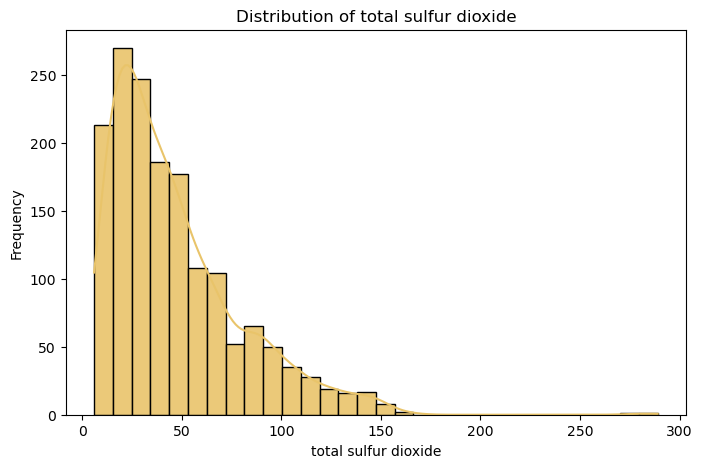

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="total sulfur dioxide",
    bins=30,
    kde=True,
    color="#E9C46A",
    alpha=0.9
)

plt.title("Distribution of total sulfur dioxide")
plt.xlabel("total sulfur dioxide")
plt.ylabel("Frequency")

plt.show()

### Distribution of density 

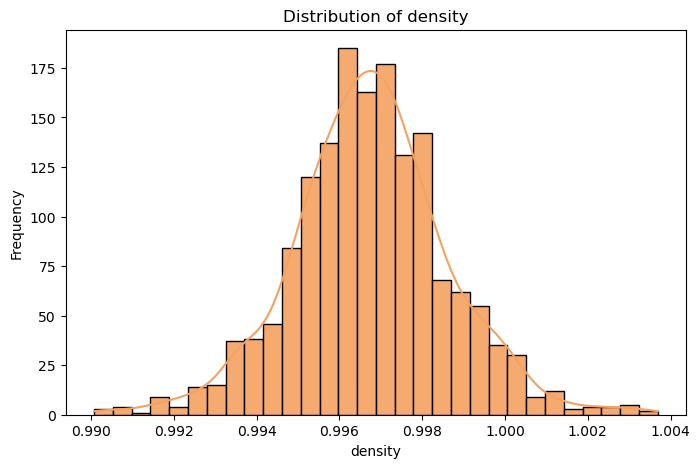

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="density",
    bins=30,
    kde=True,
    color="#F4A261",
    alpha=0.9
)

plt.title("Distribution of density")
plt.xlabel("density")
plt.ylabel("Frequency")

plt.show()

### Distribution of pH

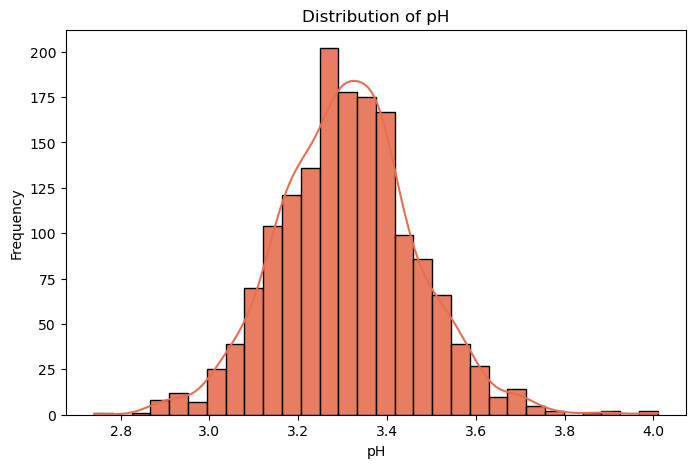

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="pH",
    bins=30,
    kde=True,
    color="#E76F51",
    alpha=0.9
)

plt.title("Distribution of pH")
plt.xlabel("pH")
plt.ylabel("Frequency")

plt.show()

### Distribution of sulphates

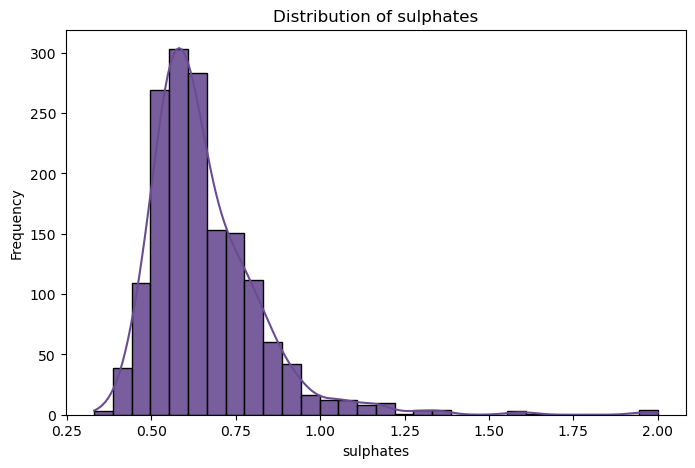

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="sulphates",
    bins=30,
    kde=True,
    color="#6A4C93",
    alpha=0.9
)

plt.title("Distribution of sulphates")
plt.xlabel("sulphates")
plt.ylabel("Frequency")

plt.show()

### Distribution of alcohol

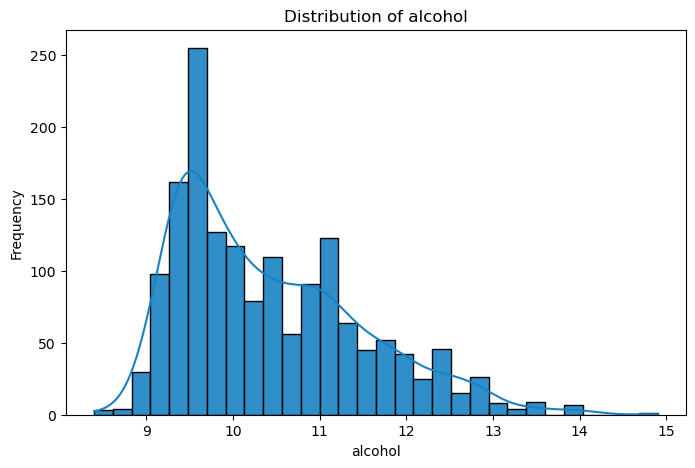

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="alcohol",
    bins=30,
    kde=True,
    color="#1982C4",
    alpha=0.9
)

plt.title("Distribution of alcohol")
plt.xlabel("alcohol")
plt.ylabel("Frequency")

plt.show()

### Creating Binary Target for quality_label
* quality >= 7 → GOOD (1)
* quality < 7 → BAD (0)

In [23]:
df["quality_label"] = np.where(df["quality"] >= 7, 1, 0)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


### Distribution of quality_label

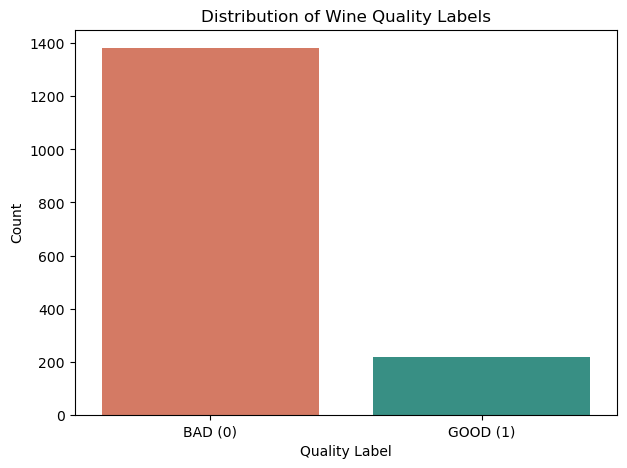

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="quality_label",
    hue="quality_label",
    palette=["#E76F51", "#2A9D8F"],
    legend=False
)

plt.title("Distribution of Wine Quality Labels")
plt.xlabel("Quality Label")
plt.ylabel("Count")

plt.xticks([0, 1], ["BAD (0)", "GOOD (1)"])

plt.show()

### Correlation Heatmap

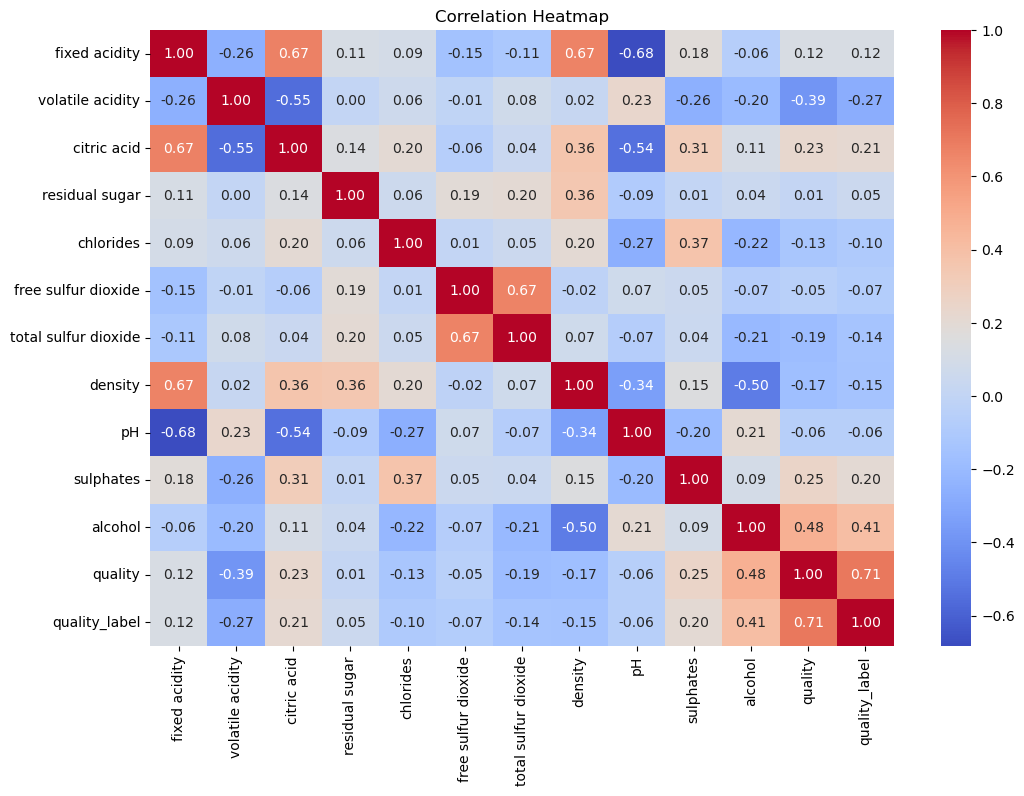

In [25]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Input & Output separation

In [26]:
X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

### Train test split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Applying Lgistic Regreesion without scaling

In [28]:
log_reg_unscaled = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg_unscaled.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Prediction by Logistic Regression

In [29]:
y_pred_log_reg_unscaled = log_reg_unscaled.predict(X_test)
y_pred_log_reg_unscaled

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,

### Logistic Regression Model Evaluation without scaling

In [30]:
log_reg_unscaled_accuracy = accuracy_score(
    y_test,
    y_pred_log_reg_unscaled
)

log_reg_unscaled_precision = precision_score(
    y_test,
    y_pred_log_reg_unscaled
)

log_reg_unscaled_recall = recall_score(
    y_test,
    y_pred_log_reg_unscaled
)

log_reg_unscaled_f1 = f1_score(
    y_test,
    y_pred_log_reg_unscaled
)
print("Logistic Regression - Without Scaling")
print("--------------------------------------")
print(f"Accuracy  : {log_reg_unscaled_accuracy:.4f}")
print(f"Precision : {log_reg_unscaled_precision:.4f}")
print(f"Recall    : {log_reg_unscaled_recall:.4f}")
print(f"F1-Score  : {log_reg_unscaled_f1:.4f}")

Logistic Regression - Without Scaling
--------------------------------------
Accuracy  : 0.8938
Precision : 0.7368
Recall    : 0.3256
F1-Score  : 0.4516


### Classification report

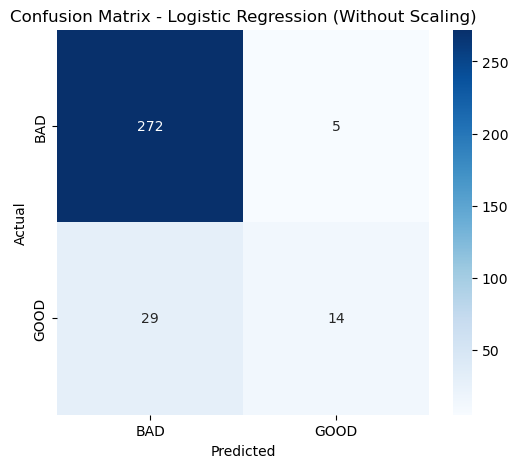

In [31]:
cm_log_reg_unscaled = confusion_matrix(
    y_test,
    y_pred_log_reg_unscaled
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_log_reg_unscaled,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BAD", "GOOD"],
    yticklabels=["BAD", "GOOD"]
)

plt.title("Confusion Matrix - Logistic Regression (Without Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
print(cm_log_reg_unscaled)

[[272   5]
 [ 29  14]]


### Logistic Regression Without Scaling 

The Logistic Regression model achieved an accuracy of **89.38%** without feature scaling.

However, the recall for the GOOD wine class was relatively low at **32.56%**, indicating that the model failed to identify many GOOD-quality wines.

The confusion matrix shows that **29 out of 43 GOOD wines were incorrectly classified as BAD**, while only 14 GOOD wines were correctly classified.

### Feature scaling

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (1279, 11)
X_test_scaled : (320, 11)


## Logistic Regression With Scaling

### Model creation

In [34]:
log_reg_scaled = LogisticRegression(
    max_iter=1000,
    random_state=42
)
log_reg_scaled.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Prediction

In [35]:
y_pred_log_reg_scaled = log_reg_scaled.predict(X_test_scaled)
y_pred_log_reg_scaled

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,

### Model Evaluation with scaled features

In [36]:
log_reg_scaled_accuracy = accuracy_score(
    y_test,
    y_pred_log_reg_scaled
)

log_reg_scaled_precision = precision_score(
    y_test,
    y_pred_log_reg_scaled
)

log_reg_scaled_recall = recall_score(
    y_test,
    y_pred_log_reg_scaled
)

log_reg_scaled_f1 = f1_score(
    y_test,
    y_pred_log_reg_scaled
)

print("Logistic Regression - With Scaling")
print("-----------------------------------")
print(f"Accuracy  : {log_reg_scaled_accuracy:.4f}")
print(f"Precision : {log_reg_scaled_precision:.4f}")
print(f"Recall    : {log_reg_scaled_recall:.4f}")
print(f"F1-Score  : {log_reg_scaled_f1:.4f}")

Logistic Regression - With Scaling
-----------------------------------
Accuracy  : 0.8938
Precision : 0.6957
Recall    : 0.3721
F1-Score  : 0.4848


### Confusion Matrix

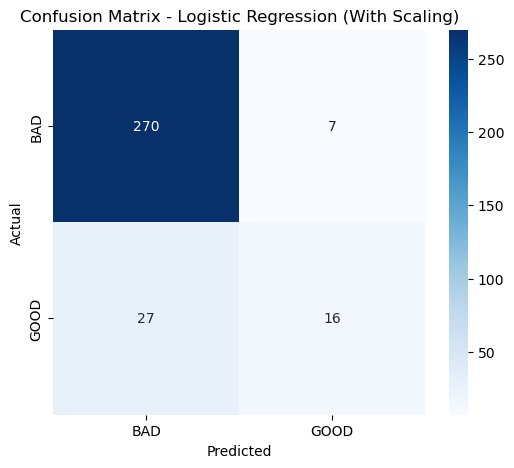

In [37]:
cm_log_reg_scaled = confusion_matrix(
    y_test,
    y_pred_log_reg_scaled
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_log_reg_scaled,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BAD", "GOOD"],
    yticklabels=["BAD", "GOOD"]
)

plt.title("Confusion Matrix - Logistic Regression (With Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Logistic Regression: Before vs After Scaling

After applying StandardScaler, the accuracy remained the same at 89.38%.
However, recall improved from 32.56% to 37.21%, and F1-score improved from 45.16% to 48.48%.

This indicates that feature scaling slightly improved the model's ability to identify GOOD-quality wines.

## KNN Without Scaling

### Model creation

In [38]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5)

knn_unscaled.fit(X_train, y_train)

KNeighborsClassifier()

### Prediction 

In [39]:
y_pred_knn_unscaled = knn_unscaled.predict(X_test)
y_pred_knn_unscaled

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,

### KNN model evaluation without feature scaling

In [40]:
knn_unscaled_accuracy = accuracy_score(
    y_test,
    y_pred_knn_unscaled
)

knn_unscaled_precision = precision_score(
    y_test,
    y_pred_knn_unscaled
)

knn_unscaled_recall = recall_score(
    y_test,
    y_pred_knn_unscaled
)

knn_unscaled_f1 = f1_score(
    y_test,
    y_pred_knn_unscaled
)

print("KNN - Without Scaling")
print("---------------------")
print(f"Accuracy  : {knn_unscaled_accuracy:.4f}")
print(f"Precision : {knn_unscaled_precision:.4f}")
print(f"Recall    : {knn_unscaled_recall:.4f}")
print(f"F1-Score  : {knn_unscaled_f1:.4f}")

KNN - Without Scaling
---------------------
Accuracy  : 0.8594
Precision : 0.4545
Recall    : 0.2326
F1-Score  : 0.3077


### Cofusion matrix

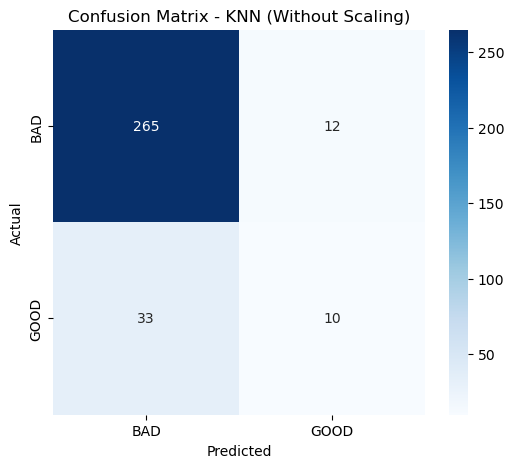

In [41]:
cm_knn_unscaled = confusion_matrix(
    y_test,
    y_pred_knn_unscaled
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn_unscaled,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BAD", "GOOD"],
    yticklabels=["BAD", "GOOD"]
)

plt.title("Confusion Matrix - KNN (Without Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### KNN With Scaling

### Model creation

In [42]:
knn_scaled = KNeighborsClassifier(n_neighbors=5)

knn_scaled.fit(X_train_scaled, y_train)

KNeighborsClassifier()

### Prediction

In [43]:
y_pred_knn_scaled = knn_scaled.predict(X_test_scaled)
y_pred_knn_scaled

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,

### KNN model evaluation with scaled features

In [44]:
knn_scaled_accuracy = accuracy_score(
    y_test,
    y_pred_knn_scaled
)

knn_scaled_precision = precision_score(
    y_test,
    y_pred_knn_scaled
)

knn_scaled_recall = recall_score(
    y_test,
    y_pred_knn_scaled
)

knn_scaled_f1 = f1_score(
    y_test,
    y_pred_knn_scaled
)

print("KNN - With Scaling")
print("------------------")
print(f"Accuracy  : {knn_scaled_accuracy:.4f}")
print(f"Precision : {knn_scaled_precision:.4f}")
print(f"Recall    : {knn_scaled_recall:.4f}")
print(f"F1-Score  : {knn_scaled_f1:.4f}")

KNN - With Scaling
------------------
Accuracy  : 0.8938
Precision : 0.6667
Recall    : 0.4186
F1-Score  : 0.5143


### Confusion Matrix

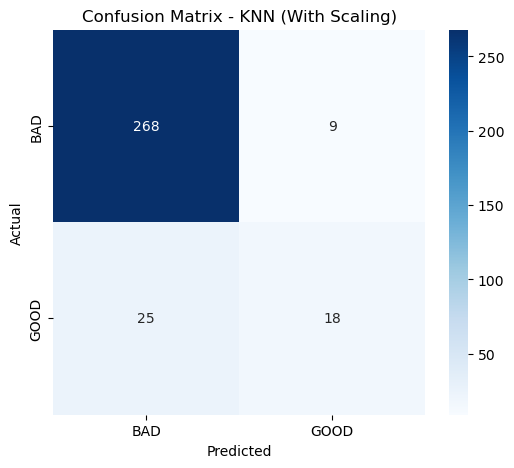

In [45]:
cm_knn_scaled = confusion_matrix(
    y_test,
    y_pred_knn_scaled
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn_scaled,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BAD", "GOOD"],
    yticklabels=["BAD", "GOOD"]
)

plt.title("Confusion Matrix - KNN (With Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### KNN: Before vs After Scaling

After applying StandardScaler, the KNN model showed significant improvement.

Accuracy increased from 85.94% to 89.38%.
Precision increased from 45.45% to 66.67%.
Recall increased from 23.26% to 41.86%.
F1-score increased from 30.77% to 51.43%.

This demonstrates that feature scaling is important for KNN because KNN uses distance-based calculations.

## Decision Tree Without Scaling

### Model creation

In [46]:
decision_tree_unscaled = DecisionTreeClassifier(
    random_state=42
)

decision_tree_unscaled.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Prediction

In [47]:
y_pred_decision_tree_unscaled = decision_tree_unscaled.predict(X_test)
y_pred_decision_tree_unscaled

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,

### Decicsion tree model evaluation wituot scaled features

In [48]:
decision_tree_unscaled_accuracy = accuracy_score(
    y_test,
    y_pred_decision_tree_unscaled
)

decision_tree_unscaled_precision = precision_score(
    y_test,
    y_pred_decision_tree_unscaled
)

decision_tree_unscaled_recall = recall_score(
    y_test,
    y_pred_decision_tree_unscaled
)

decision_tree_unscaled_f1 = f1_score(
    y_test,
    y_pred_decision_tree_unscaled
)

print("Decision Tree - Without Scaling")
print("--------------------------------")
print(f"Accuracy  : {decision_tree_unscaled_accuracy:.4f}")
print(f"Precision : {decision_tree_unscaled_precision:.4f}")
print(f"Recall    : {decision_tree_unscaled_recall:.4f}")
print(f"F1-Score  : {decision_tree_unscaled_f1:.4f}")

Decision Tree - Without Scaling
--------------------------------
Accuracy  : 0.9000
Precision : 0.6170
Recall    : 0.6744
F1-Score  : 0.6444


### Confusion Matrix

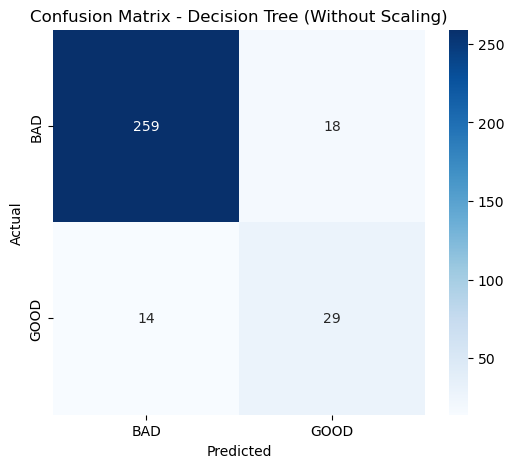

In [49]:
cm_decision_tree_unscaled = confusion_matrix(
    y_test,
    y_pred_decision_tree_unscaled
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_decision_tree_unscaled,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BAD", "GOOD"],
    yticklabels=["BAD", "GOOD"]
)

plt.title("Confusion Matrix - Decision Tree (Without Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Decision Tree With Scaling

### Model creation

In [50]:
decision_tree_scaled = DecisionTreeClassifier(
    random_state=42
)

decision_tree_scaled.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

### Prediction

In [51]:
y_pred_decision_tree_scaled = decision_tree_scaled.predict(X_test_scaled)
y_pred_decision_tree_scaled

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,

### Decision tree model evaluation with scaled features

In [52]:
decision_tree_scaled_accuracy = accuracy_score(
    y_test,
    y_pred_decision_tree_scaled
)

decision_tree_scaled_precision = precision_score(
    y_test,
    y_pred_decision_tree_scaled
)

decision_tree_scaled_recall = recall_score(
    y_test,
    y_pred_decision_tree_scaled
)

decision_tree_scaled_f1 = f1_score(
    y_test,
    y_pred_decision_tree_scaled
)

print("Decision Tree - With Scaling")
print("-----------------------------")
print(f"Accuracy  : {decision_tree_scaled_accuracy:.4f}")
print(f"Precision : {decision_tree_scaled_precision:.4f}")
print(f"Recall    : {decision_tree_scaled_recall:.4f}")
print(f"F1-Score  : {decision_tree_scaled_f1:.4f}")

Decision Tree - With Scaling
-----------------------------
Accuracy  : 0.9062
Precision : 0.6383
Recall    : 0.6977
F1-Score  : 0.6667


### Confusion Matrix

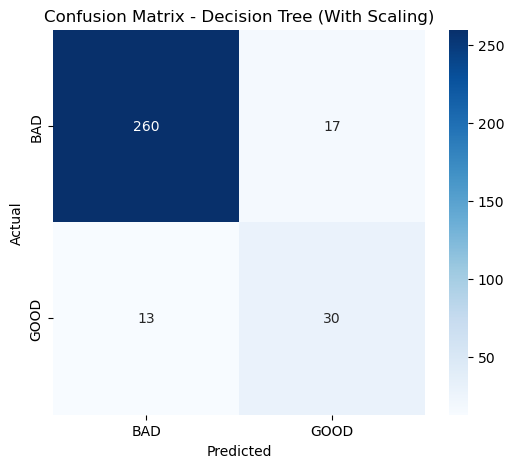

In [53]:
cm_decision_tree_scaled = confusion_matrix(
    y_test,
    y_pred_decision_tree_scaled
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_decision_tree_scaled,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BAD", "GOOD"],
    yticklabels=["BAD", "GOOD"]
)

plt.title("Confusion Matrix - Decision Tree (With Scaling)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Decision Tree: Before vs After Scaling

After applying StandardScaler, the Decision Tree showed a slight improvement in all evaluation metrics.

- Accuracy increased from 90.00% to 90.62%.
- Precision increased from 61.70% to 63.83%.
- Recall increased from 67.44% to 69.77%.
- F1-score increased from 64.44% to 66.67%.

Although Decision Trees generally do not require feature scaling, the scaled version produced slightly better results on this particular train-test split.

## Compare All Three Models

In [54]:
model_comparison_all = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression",
        "KNN",
        "KNN",
        "Decision Tree",
        "Decision Tree"
    ],
    "Scaling": [
        "Without Scaling",
        "With Scaling",
        "Without Scaling",
        "With Scaling",
        "Without Scaling",
        "With Scaling"
    ],
    "Accuracy": [
        log_reg_unscaled_accuracy,
        log_reg_scaled_accuracy,
        knn_unscaled_accuracy,
        knn_scaled_accuracy,
        decision_tree_unscaled_accuracy,
        decision_tree_scaled_accuracy
    ],
    "Precision": [
        log_reg_unscaled_precision,
        log_reg_scaled_precision,
        knn_unscaled_precision,
        knn_scaled_precision,
        decision_tree_unscaled_precision,
        decision_tree_scaled_precision
    ],
    "Recall": [
        log_reg_unscaled_recall,
        log_reg_scaled_recall,
        knn_unscaled_recall,
        knn_scaled_recall,
        decision_tree_unscaled_recall,
        decision_tree_scaled_recall
    ],
    "F1-Score": [
        log_reg_unscaled_f1,
        log_reg_scaled_f1,
        knn_unscaled_f1,
        knn_scaled_f1,
        decision_tree_unscaled_f1,
        decision_tree_scaled_f1
    ]
})

model_comparison_all
model_comparison_all.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-Score": "{:.2%}"
})

,Model,Scaling,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,Without Scaling,89.38%,73.68%,32.56%,45.16%
1,Logistic Regression,With Scaling,89.38%,69.57%,37.21%,48.48%
2,KNN,Without Scaling,85.94%,45.45%,23.26%,30.77%
3,KNN,With Scaling,89.38%,66.67%,41.86%,51.43%
4,Decision Tree,Without Scaling,90.00%,61.70%,67.44%,64.44%
5,Decision Tree,With Scaling,90.62%,63.83%,69.77%,66.67%


### Model Comparison

Three machine learning models were compared: Logistic Regression, KNN, and Decision Tree.

Among the three models, Decision Tree achieved the best overall performance with an accuracy of 90.62%, recall of 69.77%, and F1-score of 66.67%.

Therefore, Decision Tree is selected as the best-performing model for further hyperparameter tuning using GridSearchCV.

## GridSearchCV for Decision Tree

### Parameter Grid

In [55]:
param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

### Applying GridSearchCV

In [56]:
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search_dt.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1')

### Best Parameters

In [57]:
print("Best Parameters:")
print(grid_search_dt.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(grid_search_dt.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation F1-Score:
0.5254553665512569


### Tuned Decision Tree — Test Set Evaluation

In [58]:
best_decision_tree = grid_search_dt.best_estimator_

y_pred_best_dt = best_decision_tree.predict(X_test)

### Model Evaluation after the hyper parameter tuning

In [59]:
best_dt_accuracy = accuracy_score(
    y_test,
    y_pred_best_dt
)

best_dt_precision = precision_score(
    y_test,
    y_pred_best_dt
)

best_dt_recall = recall_score(
    y_test,
    y_pred_best_dt
)

best_dt_f1 = f1_score(
    y_test,
    y_pred_best_dt
)

print("Tuned Decision Tree")
print("-------------------")
print(f"Accuracy  : {best_dt_accuracy:.4f}")
print(f"Precision : {best_dt_precision:.4f}")
print(f"Recall    : {best_dt_recall:.4f}")
print(f"F1-Score  : {best_dt_f1:.4f}")

Tuned Decision Tree
-------------------
Accuracy  : 0.9250
Precision : 0.7317
Recall    : 0.6977
F1-Score  : 0.7143


### Hyperparameter Tuning 

After applying GridSearchCV, the Decision Tree model showed a significant improvement.

- Accuracy increased from 90.62% to 92.50%.
- Precision increased from 63.83% to 73.17%.
- Recall remained the same at 69.77%.
- F1-score increased from 66.67% to 71.43%.

The tuned Decision Tree achieved better overall performance than the original Decision Tree.

### Confusion Matrix of Tuned Decision Tree

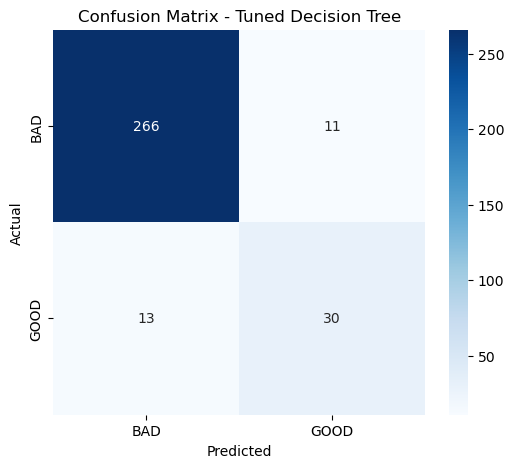

In [60]:
cm_best_dt = confusion_matrix(
    y_test,
    y_pred_best_dt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_best_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BAD", "GOOD"],
    yticklabels=["BAD", "GOOD"]
)

plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Feature Importance Analysis

In [61]:
feature_importance_dt = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_decision_tree.feature_importances_
})

feature_importance_dt = feature_importance_dt.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_dt

,Feature,Importance
10,alcohol,0.285914
9,sulphates,0.101674
1,volatile acidity,0.097330
8,pH,0.086588
6,total sulfur dioxide,0.078875
4,chlorides,0.071724
3,residual sugar,0.071398
2,citric acid,0.061351
5,free sulfur dioxide,0.058129
7,density,0.053257


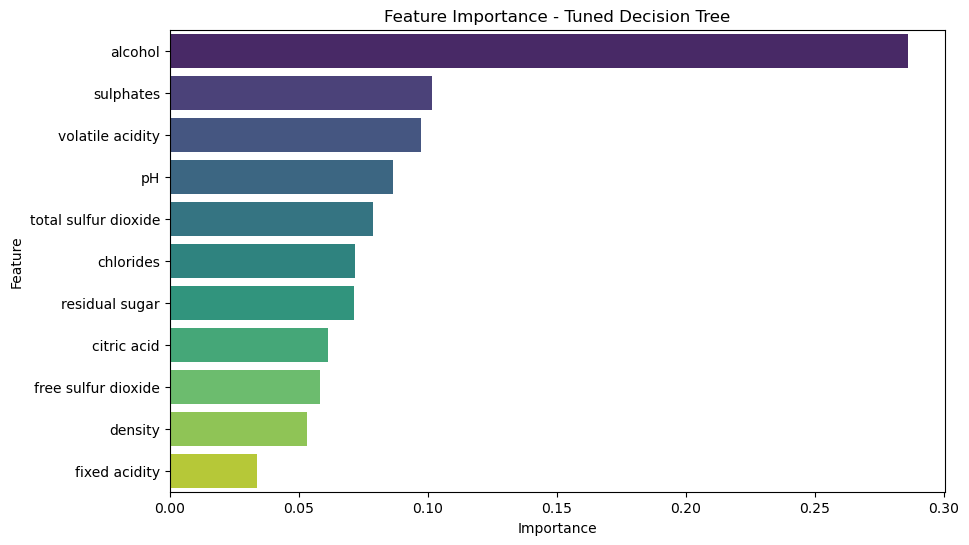

In [62]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_dt,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Importance - Tuned Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Feature Importance Analysis

Feature importance analysis was performed using the tuned Decision Tree model to identify the features that contribute most to wine quality classification.

### Key Observations

- **Alcohol** is the most important feature with an importance score of **0.2859**.
- **Sulphates** is the second most important feature with a score of **0.1017**.
- **Volatile Acidity** has an importance score of **0.0973**.
- **pH** contributes with an importance score of **0.0866**.
- **Fixed Acidity** has the lowest feature importance at **0.0338**.

Overall, alcohol has the largest contribution to the model's predictions.

### Final Model Evaluation Summary

In [63]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Tuned Decision Tree"
    ],
    "Accuracy": [
        log_reg_scaled_accuracy,
        knn_scaled_accuracy,
        decision_tree_scaled_accuracy,
        best_dt_accuracy
    ],
    "Precision": [
        log_reg_scaled_precision,
        knn_scaled_precision,
        decision_tree_scaled_precision,
        best_dt_precision
    ],
    "Recall": [
        log_reg_scaled_recall,
        knn_scaled_recall,
        decision_tree_scaled_recall,
        best_dt_recall
    ],
    "F1-Score": [
        log_reg_scaled_f1,
        knn_scaled_f1,
        decision_tree_scaled_f1,
        best_dt_f1
    ]
})

final_model_comparison.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1-Score": "{:.2%}"
})

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,89.38%,69.57%,37.21%,48.48%
1,KNN,89.38%,66.67%,41.86%,51.43%
2,Decision Tree,90.62%,63.83%,69.77%,66.67%
3,Tuned Decision Tree,92.50%,73.17%,69.77%,71.43%


## Conclusion

In this project, a Machine Learning classification model was developed to classify wine quality into two categories: **BAD (0)** and **GOOD (1)**.

The dataset was first explored using basic data analysis and Exploratory Data Analysis (EDA). Missing values and correlations between the features and wine quality were analyzed. The original `quality` variable was converted into a binary target variable called `quality_label`, where wines with quality greater than or equal to 7 were classified as GOOD and the remaining wines as BAD.

Three Machine Learning models were evaluated:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree

The models were evaluated both before and after feature scaling. Among the initial models, the **Decision Tree** achieved the best overall performance.

Hyperparameter tuning was then performed on the Decision Tree using **GridSearchCV**. The tuned Decision Tree achieved:

- **Accuracy:** 92.50%
- **Precision:** 73.17%
- **Recall:** 69.77%
- **F1-Score:** 71.43%

Therefore, the **Tuned Decision Tree** was selected as the final model for this Wine Quality Classification project.

Feature importance analysis showed that **alcohol** was the most influential feature, followed by **sulphates**, **volatile acidity**, and **pH**.

Overall, the project demonstrates how Machine Learning can be used to classify wine quality based on its chemical properties and how model scaling, comparison, and hyperparameter tuning can improve model performance.

# GUI Implementation

In [65]:
import datetime
import tkinter as tk
from tkinter import filedialog, messagebox
import customtkinter as ctk
import pandas as pd

# =========================================================
# CUSTOMTKINTER SETTINGS
# =========================================================

ctk.set_appearance_mode("light")
ctk.set_default_color_theme("blue")


# =========================================================
# CHECK MODEL
# =========================================================

try:
    model = best_decision_tree
    feature_columns = X.columns.tolist()
except NameError:
    raise Exception(
        "Model not found! Please run the ML training cells first "
        "so that 'best_decision_tree' and 'X' are available."
    )


# =========================================================
# MAIN WINDOW
# =========================================================

root = ctk.CTk()
root.title("Wine Quality Classification")
root.geometry("1160x810")

# Full Window / Maximize enabled
root.resizable(True, True)
root.configure(fg_color="#F2EBF9")


# =========================================================
# STATE VARIABLES & SAMPLE DATA
# =========================================================

last_prediction = {"text": "—", "class": "—", "raw": None}

SAMPLE_DATA = {
    "fixed acidity": "7.4",
    "volatile acidity": "0.70",
    "citric acid": "0.00",
    "residual sugar": "1.9",
    "chlorides": "0.076",
    "free sulfur dioxide": "11.0",
    "total sulfur dioxide": "34.0",
    "density": "0.9978",
    "pH": "3.51",
    "sulphates": "0.56",
    "alcohol": "9.4",
}


# =========================================================
# 1. TOP HEADER FRAME
# =========================================================

header_frame = ctk.CTkFrame(
    root, height=90, corner_radius=0, fg_color="#311352"
)
header_frame.pack(fill="x", side="top")
header_frame.pack_propagate(False)

# Left Header Info
header_left = ctk.CTkFrame(header_frame, fg_color="transparent")
header_left.pack(side="left", padx=25, pady=12)

title_icon = ctk.CTkLabel(
    header_left,
    text="🍷",
    font=("Segoe UI", 28),
    fg_color="#4A2078",
    corner_radius=22,
    width=44,
    height=44,
)
title_icon.pack(side="left", padx=(0, 15))

title_text_frame = ctk.CTkFrame(header_left, fg_color="transparent")
title_text_frame.pack(side="left")

title_label = ctk.CTkLabel(
    title_text_frame,
    text="Wine Quality Classification",
    font=("Segoe UI", 22, "bold"),
    text_color="#FFFFFF",
    anchor="w",
)
title_label.pack(anchor="w")

subtitle_label = ctk.CTkLabel(
    title_text_frame,
    text="Machine Learning Based Wine Quality Prediction",
    font=("Segoe UI", 11),
    text_color="#D8C5ED",
    anchor="w",
)
subtitle_label.pack(anchor="w")

# Right Header Buttons
header_right = ctk.CTkFrame(header_frame, fg_color="transparent")
header_right.pack(side="right", padx=25)


def toggle_theme():
    current = ctk.get_appearance_mode()
    if current == "Light":
        ctk.set_appearance_mode("Dark")
        theme_btn.configure(text="☀️ Light Mode")
    else:
        ctk.set_appearance_mode("Light")
        theme_btn.configure(text="🌙 Dark Mode")


btn_about = ctk.CTkButton(
    header_right,
    text="ⓘ About",
    width=90,
    height=32,
    corner_radius=16,
    fg_color="#FFFFFF",
    text_color="#311352",
    hover_color="#EADDF7",
    font=("Segoe UI", 12, "bold"),
    command=lambda: messagebox.showinfo(
        "About", "Wine Quality Classification System\nVersion 2.0"
    ),
)
btn_about.pack(side="left", padx=4)

btn_inst = ctk.CTkButton(
    header_right,
    text="📖 Instructions",
    width=110,
    height=32,
    corner_radius=16,
    fg_color="#FFFFFF",
    text_color="#311352",
    hover_color="#EADDF7",
    font=("Segoe UI", 12, "bold"),
    command=lambda: messagebox.showinfo(
        "Instructions",
        "1. Enter numeric values for all chemical properties.\n"
        "2. Click 'Predict Wine Quality'.\n"
        "3. Export or copy results as needed.",
    ),
)
btn_inst.pack(side="left", padx=4)

theme_btn = ctk.CTkButton(
    header_right,
    text="🌙 Dark Mode",
    width=100,
    height=32,
    corner_radius=16,
    fg_color="#FFFFFF",
    text_color="#311352",
    hover_color="#EADDF7",
    font=("Segoe UI", 12, "bold"),
    command=toggle_theme,
)
theme_btn.pack(side="left", padx=4)


# =========================================================
# 2. BOTTOM FOOTER FRAME (Packed first at bottom)
# =========================================================

footer_frame = ctk.CTkFrame(
    root, height=40, corner_radius=0, fg_color="#1E0A38"
)
footer_frame.pack(fill="x", side="bottom")
footer_frame.pack_propagate(False)

now = datetime.datetime.now()

time_label = ctk.CTkLabel(
    footer_frame,
    text=f"📅 Date: {now.strftime('%d %b %Y')}   |   ⏰ Time: {now.strftime('%I:%M %p')}",
    font=("Segoe UI", 11, "bold"),
    text_color="#E2D4F0",
)
time_label.pack(side="left", padx=20, pady=6)

footer_label = ctk.CTkLabel(
    footer_frame,
    text="Developed by Arjun Pal",
    font=("Segoe UI", 18, "bold"),
    text_color="#FFFFFF",
)
footer_label.pack(side="right", padx=20, pady=6)


# =========================================================
# 3. BOTTOM TIP BAR (Packed above footer)
# =========================================================

tip_frame = ctk.CTkFrame(root, height=32, corner_radius=8, fg_color="#F3E8FF")
tip_frame.pack(fill="x", side="bottom", padx=20, pady=(0, 8))

tip_label = ctk.CTkLabel(
    tip_frame,
    text="💡  Tip: Ensure all values are numeric and within a valid range for accurate prediction.",
    font=("Segoe UI", 10, "bold"),
    text_color="#6D28D9",
)
tip_label.pack(side="left", padx=15, pady=4)


# =========================================================
# 4. MAIN WORKSPACE (Expands in remaining space)
# =========================================================

main_frame = ctk.CTkFrame(root, fg_color="transparent")
main_frame.pack(fill="both", expand=True, padx=20, pady=(10, 8))

main_frame.grid_columnconfigure(0, weight=1)
main_frame.grid_columnconfigure(1, weight=1)
main_frame.grid_rowconfigure(0, weight=1)


# =========================================================
# LEFT - INPUT SECTION
# =========================================================

input_frame = ctk.CTkFrame(
    main_frame, fg_color="#FFFFFF", corner_radius=18
)
input_frame.grid(row=0, column=0, padx=(0, 10), pady=0, sticky="nsew")

# Title Block
input_header = ctk.CTkFrame(input_frame, fg_color="transparent")
input_header.pack(fill="x", padx=20, pady=(12, 8))

input_icon = ctk.CTkLabel(
    input_header,
    text="🧪",
    font=("Segoe UI", 16),
    fg_color="#6D28D9",
    text_color="#FFFFFF",
    width=34,
    height=34,
    corner_radius=17,
)
input_icon.pack(side="left", padx=(0, 10))

input_title_frame = ctk.CTkFrame(input_header, fg_color="transparent")
input_title_frame.pack(side="left")

input_title = ctk.CTkLabel(
    input_title_frame,
    text="Wine Features",
    font=("Segoe UI", 16, "bold"),
    text_color="#311352",
)
input_title.pack(anchor="w")

input_subtitle = ctk.CTkLabel(
    input_title_frame,
    text="Enter the chemical properties of the wine",
    font=("Segoe UI", 10),
    text_color="#6B7280",
)
input_subtitle.pack(anchor="w")


# Input Features List
feature_names = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]

display_names = [
    ("🍷", "Fixed Acidity"),
    ("🧪", "Volatile Acidity"),
    ("🍋", "Citric Acid"),
    ("🧃", "Residual Sugar"),
    ("💧", "Chlorides"),
    ("🫧", "Free Sulfur Dioxide"),
    ("🫧", "Total Sulfur Dioxide"),
    ("⚗️", "Density"),
    ("📊", "pH"),
    ("⚛️", "Sulphates"),
    ("🍷", "Alcohol"),
]

feature_entries = {}

for feature, (icon, display_name) in zip(feature_names, display_names):
    row = ctk.CTkFrame(input_frame, fg_color="transparent")
    row.pack(fill="x", padx=20, pady=2)

    icon_lbl = ctk.CTkLabel(
        row, text=icon, width=22, font=("Segoe UI", 12)
    )
    icon_lbl.pack(side="left", padx=(0, 4))

    label = ctk.CTkLabel(
        row,
        text=display_name,
        width=135,
        anchor="w",
        font=("Segoe UI", 11, "bold"),
        text_color="#374151",
    )
    label.pack(side="left")

    entry = ctk.CTkEntry(
        row,
        height=26,
        corner_radius=8,
        placeholder_text="Enter value",
        border_width=1,
        border_color="#E5E7EB",
        fg_color="#FAFAFA",
        text_color="#1F2937",
    )
    entry.pack(side="right", fill="x", expand=True, padx=(10, 0))

    feature_entries[feature] = entry


# =========================================================
# RIGHT - PREDICTION SECTION
# =========================================================

prediction_frame = ctk.CTkFrame(
    main_frame, fg_color="#FFFFFF", corner_radius=18
)
prediction_frame.grid(row=0, column=1, padx=(10, 0), pady=0, sticky="nsew")

# Title Block
pred_header = ctk.CTkFrame(prediction_frame, fg_color="transparent")
pred_header.pack(fill="x", padx=20, pady=(12, 8))

pred_icon = ctk.CTkLabel(
    pred_header,
    text="🎯",
    font=("Segoe UI", 16),
    fg_color="#6D28D9",
    text_color="#FFFFFF",
    width=34,
    height=34,
    corner_radius=17,
)
pred_icon.pack(side="left", padx=(0, 10))

pred_title_frame = ctk.CTkFrame(pred_header, fg_color="transparent")
pred_title_frame.pack(side="left")

prediction_title = ctk.CTkLabel(
    pred_title_frame,
    text="Prediction Result",
    font=("Segoe UI", 16, "bold"),
    text_color="#311352",
)
prediction_title.pack(anchor="w")

prediction_subtitle = ctk.CTkLabel(
    pred_title_frame,
    text="This is the predicted wine quality",
    font=("Segoe UI", 10),
    text_color="#6B7280",
)
prediction_subtitle.pack(anchor="w")

history_btn = ctk.CTkButton(
    pred_header,
    text="🕒 View History",
    width=95,
    height=28,
    corner_radius=14,
    fg_color="#F3E8FF",
    text_color="#6D28D9",
    hover_color="#E9D5FF",
    font=("Segoe UI", 10, "bold"),
    command=lambda: messagebox.showinfo(
        "History", "No previous predictions stored in session."
    ),
)
history_btn.pack(side="right")


# Result Display Card
result_card = ctk.CTkFrame(
    prediction_frame,
    height=135,
    corner_radius=15,
    fg_color="#F0F5FF",
    border_width=1,
    border_color="#E0E7FF",
)
result_card.pack(fill="x", padx=20, pady=8)
result_card.pack_propagate(False)

card_left = ctk.CTkFrame(result_card, fg_color="transparent")
card_left.pack(side="left", padx=20)

trophy_badge = ctk.CTkLabel(
    card_left,
    text="🏆",
    font=("Segoe UI", 28),
    fg_color="#FFFFFF",
    width=58,
    height=58,
    corner_radius=29,
)
trophy_badge.pack()

card_center = ctk.CTkFrame(result_card, fg_color="transparent")
card_center.pack(side="left", padx=10, expand=True)

result_heading = ctk.CTkLabel(
    card_center,
    text="Wine Quality",
    font=("Segoe UI", 12, "bold"),
    text_color="#4B5563",
)
result_heading.pack(anchor="w")

result_label = ctk.CTkLabel(
    card_center,
    text="— — —",
    font=("Segoe UI", 26, "bold"),
    text_color="#10B981",
)
result_label.pack(anchor="w")

class_label = ctk.CTkLabel(
    card_center,
    text="Class: —",
    font=("Segoe UI", 12, "bold"),
    text_color="#059669",
)
class_label.pack(anchor="w")


# =========================================================
# ACTION BUTTONS GRID
# =========================================================

btn_grid = ctk.CTkFrame(prediction_frame, fg_color="transparent")
btn_grid.pack(fill="x", padx=20, pady=8)

btn_grid.grid_columnconfigure(0, weight=1)
btn_grid.grid_columnconfigure(1, weight=1)


# Core Logic Callbacks
def predict_wine_quality():
    try:
        values = []
        for feature in feature_names:
            value = feature_entries[feature].get().strip()
            if value == "":
                messagebox.showwarning(
                    "Missing Input",
                    f"Please enter a value for:\n{feature.title()}",
                )
                return
            values.append(float(value))

        input_data = pd.DataFrame([values], columns=feature_columns)
        prediction = model.predict(input_data)[0]

        if prediction == 1:
            result_label.configure(text="GOOD WINE", text_color="#10B981")
            class_label.configure(text="Class: 1 (GOOD)", text_color="#059669")
            last_prediction["text"] = "GOOD WINE"
            last_prediction["class"] = "Class: 1 (GOOD)"
        else:
            result_label.configure(text="BAD WINE", text_color="#EF4444")
            class_label.configure(text="Class: 0 (BAD)", text_color="#DC2626")
            last_prediction["text"] = "BAD WINE"
            last_prediction["class"] = "Class: 0 (BAD)"

        last_prediction["raw"] = values

    except ValueError:
        messagebox.showerror(
            "Invalid Input", "Please enter valid numeric values only."
        )
    except Exception as error:
        messagebox.showerror("Prediction Error", str(error))


def clear_fields():
    for entry in feature_entries.values():
        entry.delete(0, tk.END)

    result_label.configure(text="— — —", text_color="#10B981")
    class_label.configure(text="Class: —", text_color="#059669")
    last_prediction["text"] = "—"
    last_prediction["class"] = "—"
    last_prediction["raw"] = None


def export_result():
    if last_prediction["raw"] is None:
        messagebox.showwarning(
            "Export Warning", "Please run a prediction first."
        )
        return

    path = filedialog.asksaveasfilename(
        defaultextension=".csv", filetypes=[("CSV Files", "*.csv")]
    )
    if path:
        data = dict(zip(feature_names, last_prediction["raw"]))
        data["Prediction"] = last_prediction["text"]
        data["Class"] = last_prediction["class"]
        pd.DataFrame([data]).to_csv(path, index=False)
        messagebox.showinfo("Export Success", "Result exported successfully!")


def copy_result():
    if last_prediction["text"] == "—":
        messagebox.showwarning(
            "Copy Warning", "No prediction result to copy."
        )
        return

    text_to_copy = (
        f"Wine Quality Result: {last_prediction['text']} "
        f"({last_prediction['class']})"
    )
    root.clipboard_clear()
    root.clipboard_append(text_to_copy)
    messagebox.showinfo("Copied")


def load_sample_data():
    for feat, val in SAMPLE_DATA.items():
        if feat in feature_entries:
            feature_entries[feat].delete(0, tk.END)
            feature_entries[feat].insert(0, val)


# 1. Predict Button (Purple)
btn_predict = ctk.CTkButton(
    btn_grid,
    text="🔍  Predict Wine Quality",
    font=("Segoe UI", 11, "bold"),
    height=48,
    corner_radius=10,
    fg_color="#6D28D9",
    hover_color="#5B21B6",
    anchor="w",
    command=predict_wine_quality,
)
btn_predict.grid(row=0, column=0, padx=(0, 4), pady=4, sticky="ew")

# 2. Clear All Button (Blue)
btn_clear = ctk.CTkButton(
    btn_grid,
    text="🔄  Clear All",
    font=("Segoe UI", 11, "bold"),
    height=48,
    corner_radius=10,
    fg_color="#2563EB",
    hover_color="#1D4ED8",
    anchor="w",
    command=clear_fields,
)
btn_clear.grid(row=0, column=1, padx=(4, 0), pady=4, sticky="ew")

# 3. Export Result Button (Green)
btn_export = ctk.CTkButton(
    btn_grid,
    text="📥 Save Result",
    font=("Segoe UI", 11, "bold"),
    height=48,
    corner_radius=10,
    fg_color="#10B981",
    hover_color="#059669",
    anchor="w",
    command=export_result,
)
btn_export.grid(row=1, column=0, padx=(0, 4), pady=4, sticky="ew")

# 4. Copy Result Button (Orange)
btn_copy = ctk.CTkButton(
    btn_grid,
    text="📋  Copy Result",
    font=("Segoe UI", 11, "bold"),
    height=48,
    corner_radius=10,
    fg_color="#F97316",
    hover_color="#EA580C",
    anchor="w",
    command=copy_result,
)
btn_copy.grid(row=1, column=1, padx=(4, 0), pady=4, sticky="ew")

# 5. Use Sample Data Button (Teal / Wide)
btn_sample = ctk.CTkButton(
    prediction_frame,
    text="🧪  Use Sample Data ",
    font=("Segoe UI", 11, "bold"),
    height=48,
    corner_radius=10,
    fg_color="#06B6D4",
    hover_color="#0891B2",
    anchor="w",
    command=load_sample_data,
)
btn_sample.pack(fill="x", padx=20, pady=(4, 10))


# =========================================================
# RUN GUI
# =========================================================

root.mainloop()